In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

from emcee import EnsembleSampler
from trianglechain import TriangleChain

from msi.gaussian_likelihood.dense_emulator import DenseEmulator

from msi.utils import input_output, plotting
from msfm.utils import prior, parameters

23-07-04 10:02:53    scales.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
method_label = "gaussian_likelihood"

### choose a run

In [4]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"

In [5]:
# clustering only
model_dir = "2023-05-30_01-48-23_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "bg", "n_bg"]

In [6]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [7]:
# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [8]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

In [9]:
fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)

23-07-04 10:02:53 input_output INF   Array shapes:
 
23-07-04 10:02:53 input_output INF   fidu_train_preds =   (750, 4) 
23-07-04 10:02:53 input_output INF   fidu_vali_preds =    (50, 4) 
23-07-04 10:02:53 input_output INF   grid_preds =         (2499, 16, 4) 
23-07-04 10:02:53 input_output INF   grid_cosmos =        (2499, 4) 
23-07-04 10:02:53 input_output INF   grid_sobol =         (2499, 4) 


### observation

In [10]:
obs_pred = np.median(fidu_vali_preds, axis=0)

# Gaussian likelihood

### Covariance

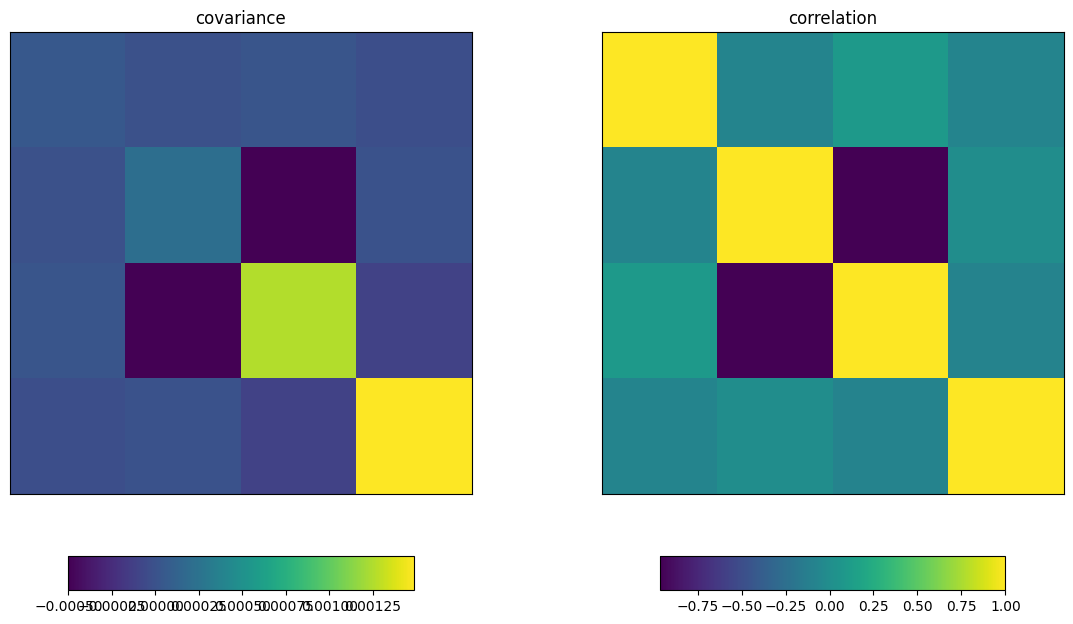

In [11]:
fid_cov = np.cov(fidu_vali_preds, rowvar=False)
fid_corr = np.corrcoef(fidu_vali_preds, rowvar=False)

fig, ax = plt.subplots(figsize=(14,8), ncols=2)

# covariance
im = ax[0].imshow(fid_cov)
ax[0].set(title="covariance")
ax[0].set_xticks([])
ax[0].set_yticks([])

fig.colorbar(im, ax=ax[0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1].imshow(fid_corr)
ax[1].set(title="correlation")
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.colorbar(im, ax=ax[1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

### prepare the training set

In [12]:
# spread the validation set evenly over the whole Sobol sequence in parameter space
split_index = -3

y_train = np.concatenate(grid_preds[:,:split_index,:], axis=0)
x_train = np.repeat(grid_cosmos, y_train.shape[0]//grid_cosmos.shape[0], axis=0)
print(y_train.shape)
print(x_train.shape)

y_vali = np.concatenate(grid_preds[:,split_index:,:], axis=0)
x_vali = np.repeat(grid_cosmos, y_vali.shape[0]//grid_cosmos.shape[0], axis=0)
print(x_vali.shape)
print(y_vali.shape)

(32487, 4)
(32487, 4)
(7497, 4)
(7497, 4)


### dense emulator network

In [13]:
emu = DenseEmulator(x_train.shape[-1], y_train.shape[-1], n_units=1024, n_layers=4, dropout_rate=0.2)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4)]               0         
                                                                 
 tf.math.subtract (TFOpLambd  (None, 4)                0         
 a)                                                              
                                                                 
 tf.math.truediv (TFOpLambda  (None, 4)                0         
 )                                                               
                                                                 
 dense (Dense)               (None, 1024)              5120      
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 1024)              104960

In [14]:
history = emu.fit(
    x_train, 
    y_train, 
    validation_data=(x_vali, y_vali), 
    batch_size=2499, 
    epochs=1000, 
    early_stopping_callback=True, 
    learning_rate_callback=True
)

23-07-04 10:02:55 dense_emulat INF   Preprocessing scalers have been successfully fit 


epoch:  30%|██▉       | 295/1000 [00:28<01:06, 10.66it/s, loss=0.00459, val_loss=0.00329, lr=7.81e-6] 

Restoring model weights from the end of the best epoch: 196.


epoch:  30%|██▉       | 296/1000 [00:28<01:06, 10.66it/s, loss=0.00457, val_loss=0.00323, lr=7.81e-6]

Epoch 296: early stopping


epoch:  30%|██▉       | 296/1000 [00:28<01:07, 10.48it/s, loss=0.00457, val_loss=0.00323, lr=7.81e-6]


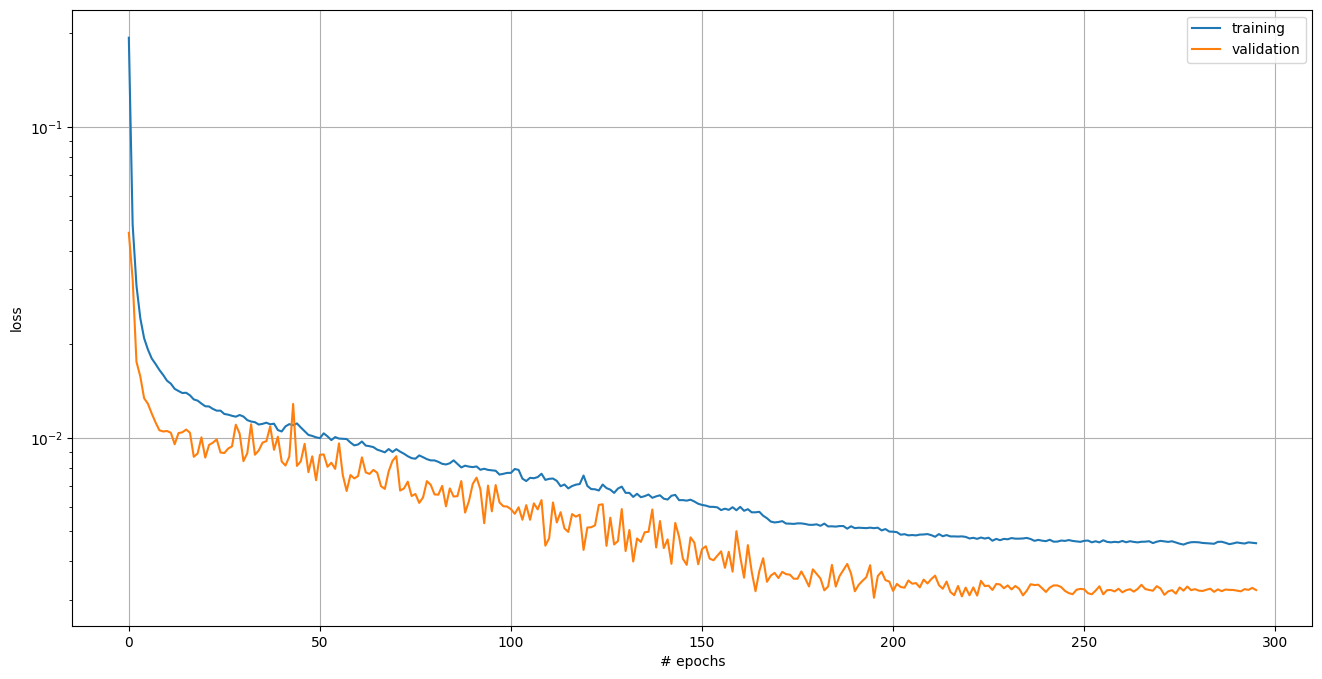

In [15]:
# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
ax.grid(True)

# MCMC

In [16]:
tf_cholesky = tf.linalg.cholesky(tf.cast(fid_cov, dtype=tf.float32))
tf_pred = tf.cast(obs_pred, dtype=tf.float32)

def log_posterior(X): 
    # X = emu.scale_forward_x(X)
    normal = tfp.distributions.MultivariateNormalTriL(
        loc=emu(X), 
        scale_tril=tf_cholesky,
    )

    # evaluate the normal distribution
    log_prob = normal.log_prob(tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

In [17]:
assert len(params) == x_train.shape[-1] == y_train.shape[-1]
summary_dim = len(params)

# emcee setup
np.random.seed(42)

n_walkers = 1024
p0 = np.random.normal(loc=parameters.get_fiducials(params), scale=1e-3, size=(n_walkers, summary_dim))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=params))) 

Initial values in prior:  True


In [18]:
# sample burn in
sampler = EnsembleSampler(n_walkers, summary_dim, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()

# run the actual chain
sampler.run_mcmc(state, 1000, progress=True)

# save the result
chain = sampler.get_chain(flat=True)
np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_{method_label}.npy"), chain)

100%|██████████| 1000/1000 [01:15<00:00, 13.25it/s]


# plot

### compare GP ABC to normalizing flow

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

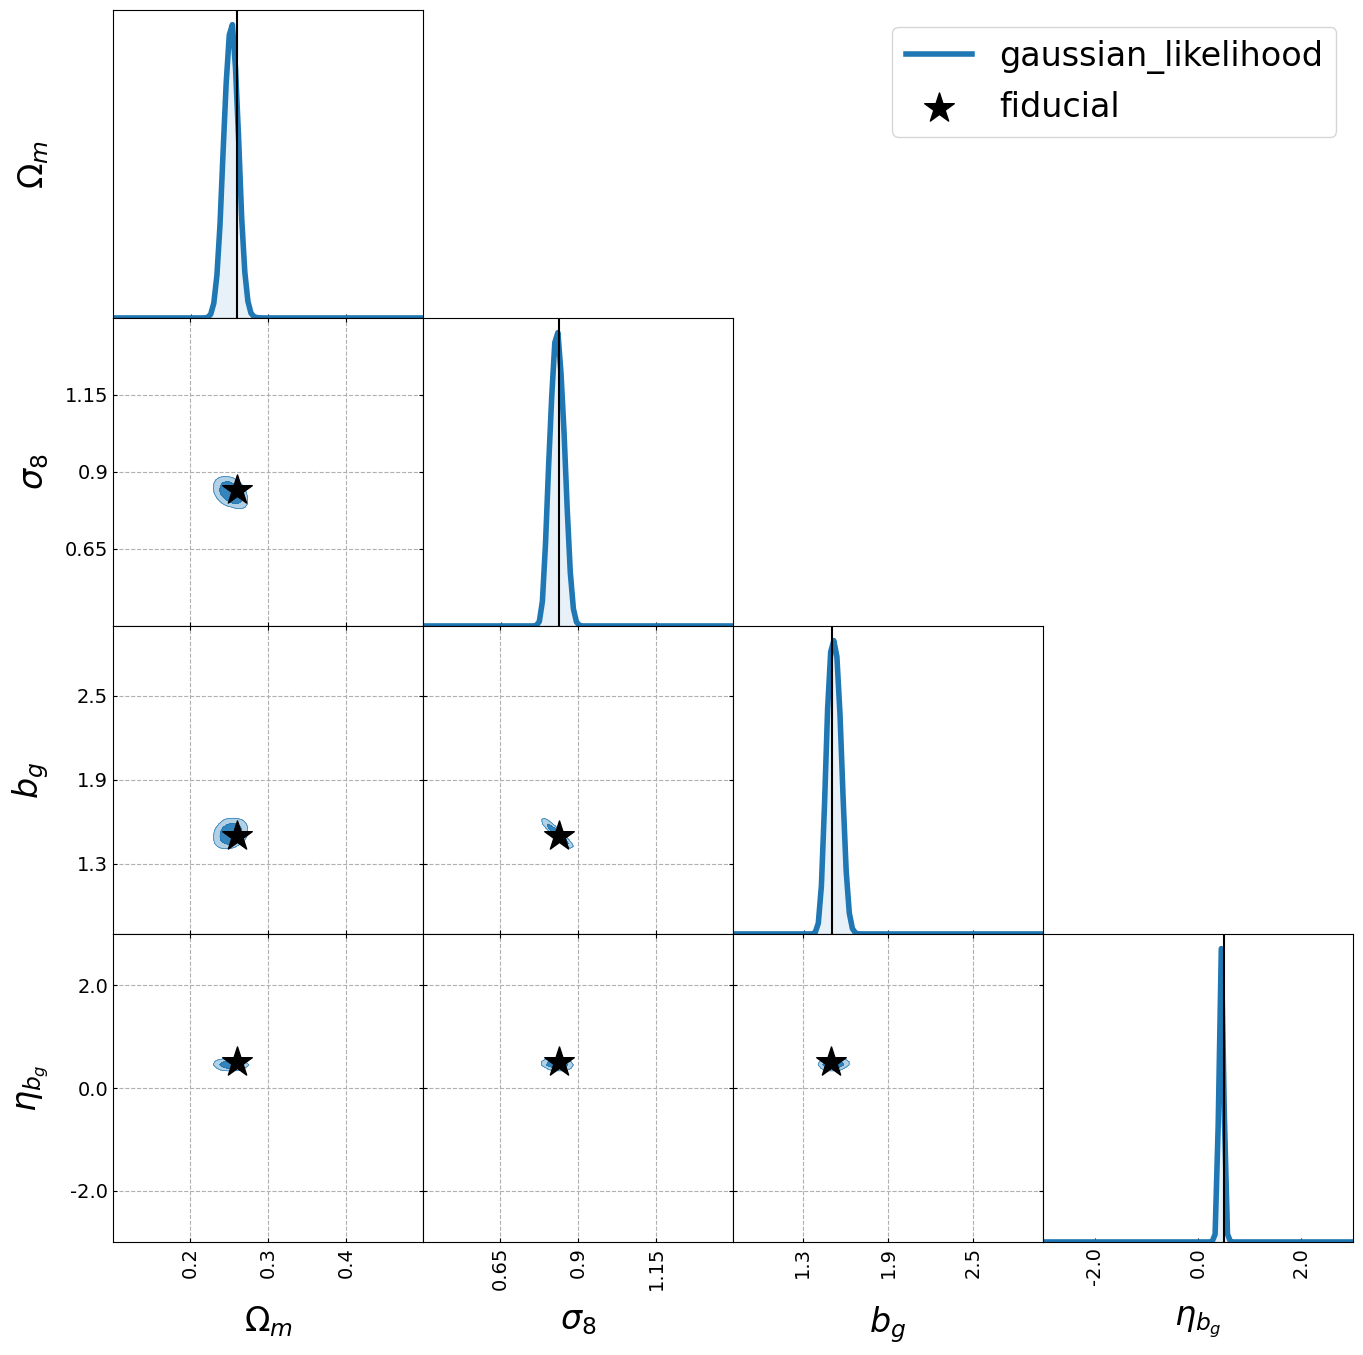

In [19]:
plotting.plot_chain(chain, params, out_dir=os.path.join(base_dir, model_dir), method_label=method_label)